# E-Commerce Recommendation Engine

## Phase 0: Setup & Libraries Installation

In [1]:
# ========================================
# CELL 2: IMPORT ALL LIBRARIES
# ========================================

# Suppress warnings for cleaner output
import warnings
warnings.filterwarnings('ignore')

# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning - sklearn
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

# Surprise library for collaborative filtering
from surprise import Dataset, Reader, SVD, KNNBasic
from surprise.model_selection import train_test_split as surprise_train_test_split
from surprise import accuracy

# PyTorch
import torch
from torch.utils.data import DataLoader, Dataset as TorchDataset
import torch.nn as nn
import torch.optim as optim

# Transformers
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer
)

# Dataset loading
from datasets import load_dataset

# Progress bars
from tqdm.auto import tqdm

# Configure plotting style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

print("✓ All libraries imported successfully!")

✓ All libraries imported successfully!


In [2]:
# ========================================
# CELL 3: VERIFY GPU & LIBRARY VERSIONS
# ========================================

print("=" * 60)
print("LIBRARY STATUS")
print("=" * 60)

# Core libraries
print(f"\n📦 Core Libraries:")
print(f"   numpy:        {np.__version__}")
print(f"   pandas:       {pd.__version__}")
print(f"   matplotlib:   {plt.matplotlib.__version__}")
print(f"   seaborn:      {sns.__version__}")

# ML libraries
import sklearn
import surprise
print(f"\n🤖 ML Libraries:")
print(f"   scikit-learn: {sklearn.__version__}")
print(f"   surprise:     {surprise.__version__}")

# Deep Learning
import transformers
print(f"\n🧠 Deep Learning:")
print(f"   torch:        {torch.__version__}")
print(f"   transformers: {transformers.__version__}")

# GPU Status
print(f"\n🎮 GPU STATUS:")
if torch.cuda.is_available():
    print(f"   CUDA Available:  ✓ Yes")
    print(f"   CUDA Version:    {torch.version.cuda}")
    print(f"   GPU Device:      {torch.cuda.get_device_name(0)}")
    print(f"   GPU Memory:      {torch.cuda.get_device_properties(0).total_memory / 1024**3:.1f} GB")
    
    # Quick GPU test
    test_tensor = torch.tensor([1.0, 2.0, 3.0]).cuda()
    print(f"   GPU Test:        ✓ Tensor operations working")
else:
    print(f"   CUDA Available:  ✗ No")
    print(f"   Training will use CPU (slower)")

print("\n" + "=" * 60)
print("✓ Environment ready for training!")
print("=" * 60)

LIBRARY STATUS

📦 Core Libraries:
   numpy:        1.26.4
   pandas:       2.3.3
   matplotlib:   3.10.8
   seaborn:      0.13.2

🤖 ML Libraries:
   scikit-learn: 1.7.2
   surprise:     1.1.4

🧠 Deep Learning:
   torch:        2.6.0+cu124
   transformers: 4.57.6

🎮 GPU STATUS:
   CUDA Available:  ✓ Yes
   CUDA Version:    12.4
   GPU Device:      NVIDIA GeForce GTX 1660 SUPER
   GPU Memory:      5.6 GB
   GPU Test:        ✓ Tensor operations working

✓ Environment ready for training!


In [3]:
# ========================================
# CELL 4: SET DEVICE FOR TRAINING
# ========================================

# Automatically select best available device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

if device.type == 'cuda':
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    # Set memory management for better performance on 6GB cards
    torch.cuda.empty_cache()
    print("GPU memory cache cleared")

Using device: cuda
GPU: NVIDIA GeForce GTX 1660 SUPER
GPU memory cache cleared


In [4]:
# !pip install --user --ignore-installed matplotlib
# !pip install --user --ignore-installed numpy pandas seaborn

## Phase 1: Setup & Imports

In [5]:
import pandas as pd
import os
from datasets import load_dataset
import matplotlib.pyplot as plt
import seaborn as sns

## Phase 2: Data Loading

In [ ]:
# # Create data directory
# os.makedirs(os.path.expanduser('~/Desktop/Hireable/data/'), exist_ok=True)

# # Download dataset using wget
# !wget -O ~/Desktop/Hireable/data/amazon_reviews.csv.gz https://snap.stanford.edu/data/finefoods.txt.gz

# # Extract the file
# !gunzip ~/Desktop/Hireable/data/amazon_reviews.csv.gz

--2026-01-15 11:06:46--  https://snap.stanford.edu/data/finefoods.txt.gz
Resolving snap.stanford.edu (snap.stanford.edu)... 171.64.75.80
Connecting to snap.stanford.edu (snap.stanford.edu)|171.64.75.80|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 122104202 (116M) [application/x-gzip]
Saving to: ‘/home/zigron/Desktop/Hireable/data/amazon_reviews.csv.gz’

/home/zigron/Deskto 100%[===================>] 116.45M   194KB/s    in 13m 25s 

2026-01-15 11:20:14 (148 KB/s) - ‘/home/zigron/Desktop/Hireable/data/amazon_reviews.csv.gz’ saved [122104202/122104202]

gzip: /home/zigron/Desktop/Hireable/data/amazon_reviews.csv already exists; do you wish to overwrite (y or n)? 

## Phase 3: Exploratory Data Analysis (EDA)

In [6]:
# Parse the file correctly
data = []
entry = {}

with open(os.path.expanduser('~/Desktop/Hireable/data/amazon_reviews.csv'), 'r', encoding='latin1') as f:
    for line in f:
        line = line.strip()
        colon_pos = line.find(':')
        
        if colon_pos == -1:  # No colon means end of review entry
            if entry:
                data.append(entry)
                entry = {}
            continue
        
        # Split at first colon
        key = line[:colon_pos]
        value = line[colon_pos+2:]  # Skip ': '
        entry[key] = value
    
    # Add last entry
    if entry:
        data.append(entry)

# Convert to DataFrame
df = pd.DataFrame(data)

# Display info
print(f"Dataset shape: {df.shape}")
print(f"\nColumns: {df.columns.tolist()}")
print(f"\nFirst few rows:")
print(df.head())
df

Dataset shape: (568461, 8)

Columns: ['product/productId', 'review/userId', 'review/profileName', 'review/helpfulness', 'review/score', 'review/time', 'review/summary', 'review/text']

First few rows:
  product/productId   review/userId               review/profileName  \
0        B001E4KFG0  A3SGXH7AUHU8GW                       delmartian   
1        B00813GRG4  A1D87F6ZCVE5NK                           dll pa   
2        B000LQOCH0   ABXLMWJIXXAIN  Natalia Corres "Natalia Corres"   
3        B000UA0QIQ  A395BORC6FGVXV                             Karl   
4        B006K2ZZ7K  A1UQRSCLF8GW1T    Michael D. Bigham "M. Wassir"   

  review/helpfulness review/score review/time         review/summary  \
0                1/1          5.0  1303862400  Good Quality Dog Food   
1                0/0          1.0  1346976000      Not as Advertised   
2                1/1          4.0  1219017600  "Delight" says it all   
3                3/3          2.0  1307923200         Cough Medicine   
4     

,product/productId,review/userId,review/profileName,review/helpfulness,review/score,review/time,review/summary,review/text
0,B001E4KFG0,A3SGXH7AUHU8GW,delmartian,1/1,5.0,1303862400,Good Quality Dog Food,I have bought several of the Vitality canned d...
1,B00813GRG4,A1D87F6ZCVE5NK,dll pa,0/0,1.0,1346976000,Not as Advertised,Product arrived labeled as Jumbo Salted Peanut...
2,B000LQOCH0,ABXLMWJIXXAIN,"Natalia Corres ""Natalia Corres""",1/1,4.0,1219017600,"""Delight"" says it all",This is a confection that has been around a fe...
3,B000UA0QIQ,A395BORC6FGVXV,Karl,3/3,2.0,1307923200,Cough Medicine,If you are looking for the secret ingredient i...
4,B006K2ZZ7K,A1UQRSCLF8GW1T,"Michael D. Bigham ""M. Wassir""",0/0,5.0,1350777600,Great taffy,Great taffy at a great price. There was a wid...
...,...,...,...,...,...,...,...,...
568456,B001EO7N10,A28KG5XORO54AY,Lettie D. Carter,0/0,5.0,1299628800,Will not do without,Great for sesame chicken..this is a good if no...
568457,B003S1WTCU,A3I8AFVPEE8KI5,R. Sawyer,0/0,2.0,1331251200,disappointed,I'm disappointed with the flavor. The chocolat...
568458,B004I613EE,A121AA1GQV751Z,"pksd ""pk_007""",2/2,5.0,1329782400,Perfect for our maltipoo,"These stars are small, so you can give 10-15 o..."
568459,B004I613EE,A3IBEVCTXKNOH,"Kathy A. Welch ""katwel""",1/1,5.0,1331596800,Favorite Training and reward treat,These are the BEST treats for training and rew...


### Setup & Data Preparation

In [7]:

# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# Convert columns to proper types
df['review/score'] = pd.to_numeric(df['review/score'], errors='coerce')
df['review/time'] = pd.to_numeric(df['review/time'], errors='coerce')

# Add review length column
df['ReviewLength'] = df['review/text'].astype(str).apply(len)

print("Data prepared for EDA!")
print(f"Total reviews: {len(df)}")
print(f"\nBasic Statistics:")
print(df[['review/score', 'ReviewLength']].describe())

Data prepared for EDA!
Total reviews: 568461

Basic Statistics:
        review/score   ReviewLength
count  568454.000000  568461.000000
mean        4.183199     436.216748
std         1.310436     445.339594
min         1.000000       3.000000
25%         4.000000     179.000000
50%         5.000000     302.000000
75%         5.000000     527.000000
max         5.000000   21409.000000


### Rating Distribution

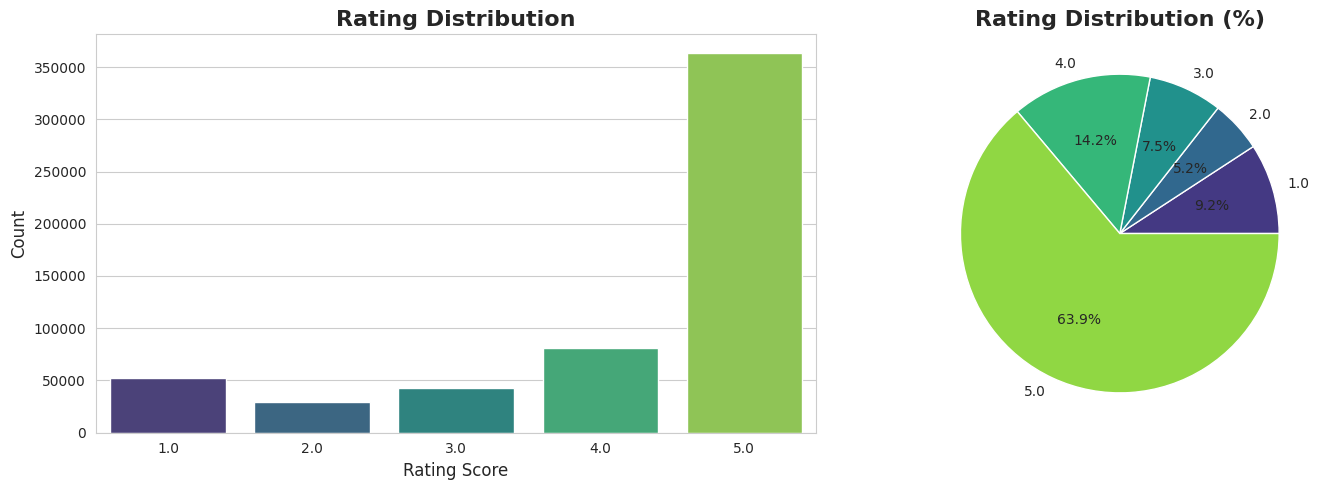


Rating Statistics:
review/score
1.0     52268
2.0     29769
3.0     42640
4.0     80655
5.0    363122
Name: count, dtype: int64


In [8]:
# Rating distribution
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Bar plot
sns.countplot(data=df, x='review/score', palette='viridis', ax=axes[0])
axes[0].set_title('Rating Distribution', fontsize=16, fontweight='bold')
axes[0].set_xlabel('Rating Score', fontsize=12)
axes[0].set_ylabel('Count', fontsize=12)

# Pie chart
rating_counts = df['review/score'].value_counts().sort_index()
axes[1].pie(rating_counts, labels=rating_counts.index, autopct='%1.1f%%', 
            colors=sns.color_palette('viridis', len(rating_counts)))
axes[1].set_title('Rating Distribution (%)', fontsize=16, fontweight='bold')

plt.tight_layout()
plt.show()

print(f"\nRating Statistics:")
print(df['review/score'].value_counts().sort_index())

### Review Length Analysis

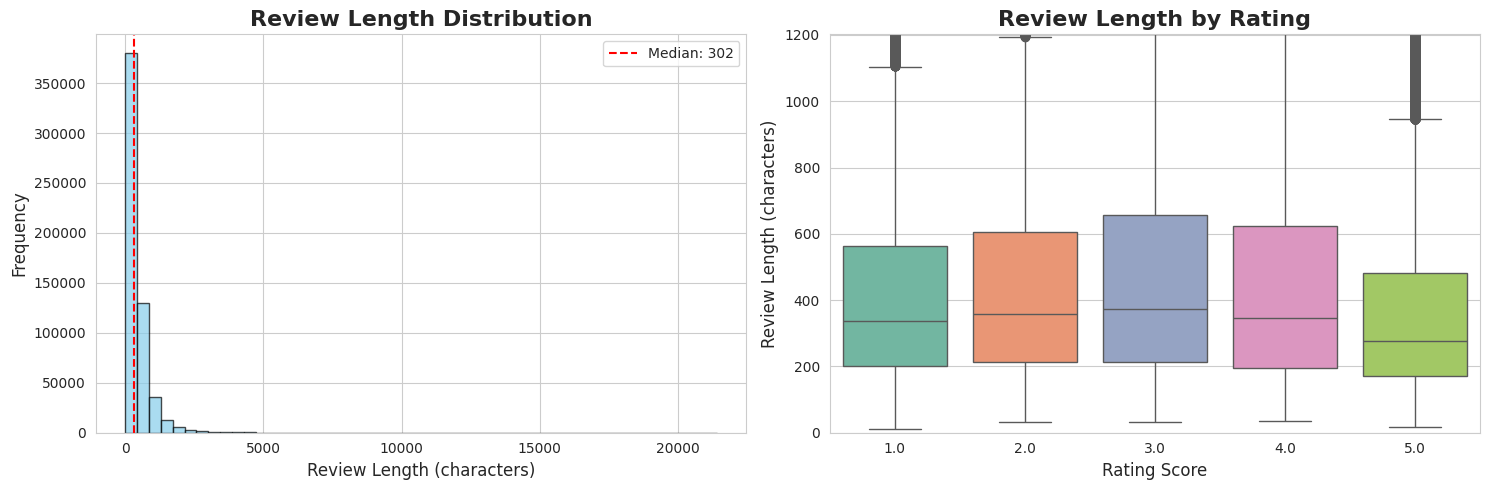

In [9]:
# Review length distribution
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Histogram
axes[0].hist(df['ReviewLength'], bins=50, color='skyblue', edgecolor='black', alpha=0.7)
axes[0].set_title('Review Length Distribution', fontsize=16, fontweight='bold')
axes[0].set_xlabel('Review Length (characters)', fontsize=12)
axes[0].set_ylabel('Frequency', fontsize=12)
axes[0].axvline(df['ReviewLength'].median(), color='red', linestyle='--', label=f'Median: {df["ReviewLength"].median():.0f}')
axes[0].legend()

# Box plot by rating
sns.boxplot(data=df, x='review/score', y='ReviewLength', palette='Set2', ax=axes[1])
axes[1].set_title('Review Length by Rating', fontsize=16, fontweight='bold')
axes[1].set_xlabel('Rating Score', fontsize=12)
axes[1].set_ylabel('Review Length (characters)', fontsize=12)
axes[1].set_ylim(0, df['ReviewLength'].quantile(0.95))

plt.tight_layout()
plt.show()

### Time Series Analysis

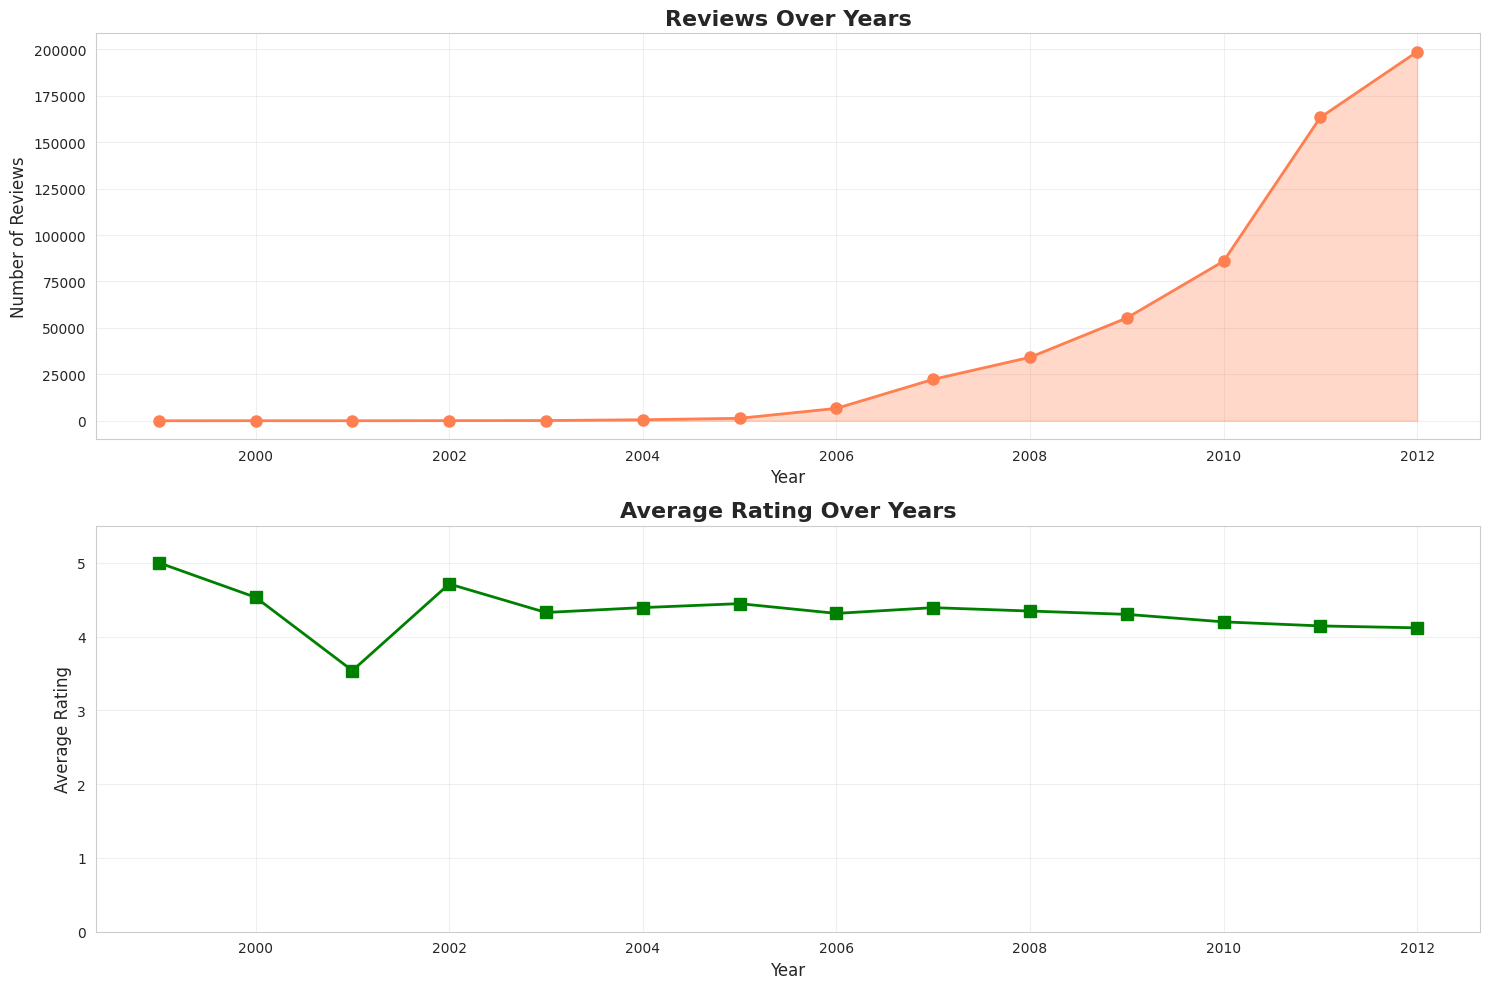

In [10]:
# Convert timestamp to datetime
df['Date'] = pd.to_datetime(df['review/time'], unit='s')
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.to_period('M')

# Reviews over time
fig, axes = plt.subplots(2, 1, figsize=(15, 10))

# Reviews per year
yearly_reviews = df['Year'].value_counts().sort_index()
axes[0].plot(yearly_reviews.index, yearly_reviews.values, marker='o', linewidth=2, markersize=8, color='coral')
axes[0].fill_between(yearly_reviews.index, yearly_reviews.values, alpha=0.3, color='coral')
axes[0].set_title('Reviews Over Years', fontsize=16, fontweight='bold')
axes[0].set_xlabel('Year', fontsize=12)
axes[0].set_ylabel('Number of Reviews', fontsize=12)
axes[0].grid(True, alpha=0.3)

# Average rating over years
yearly_avg = df.groupby('Year')['review/score'].mean()
axes[1].plot(yearly_avg.index, yearly_avg.values, marker='s', linewidth=2, markersize=8, color='green')
axes[1].set_title('Average Rating Over Years', fontsize=16, fontweight='bold')
axes[1].set_xlabel('Year', fontsize=12)
axes[1].set_ylabel('Average Rating', fontsize=12)
axes[1].set_ylim(0, 5.5)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Top Products & Users

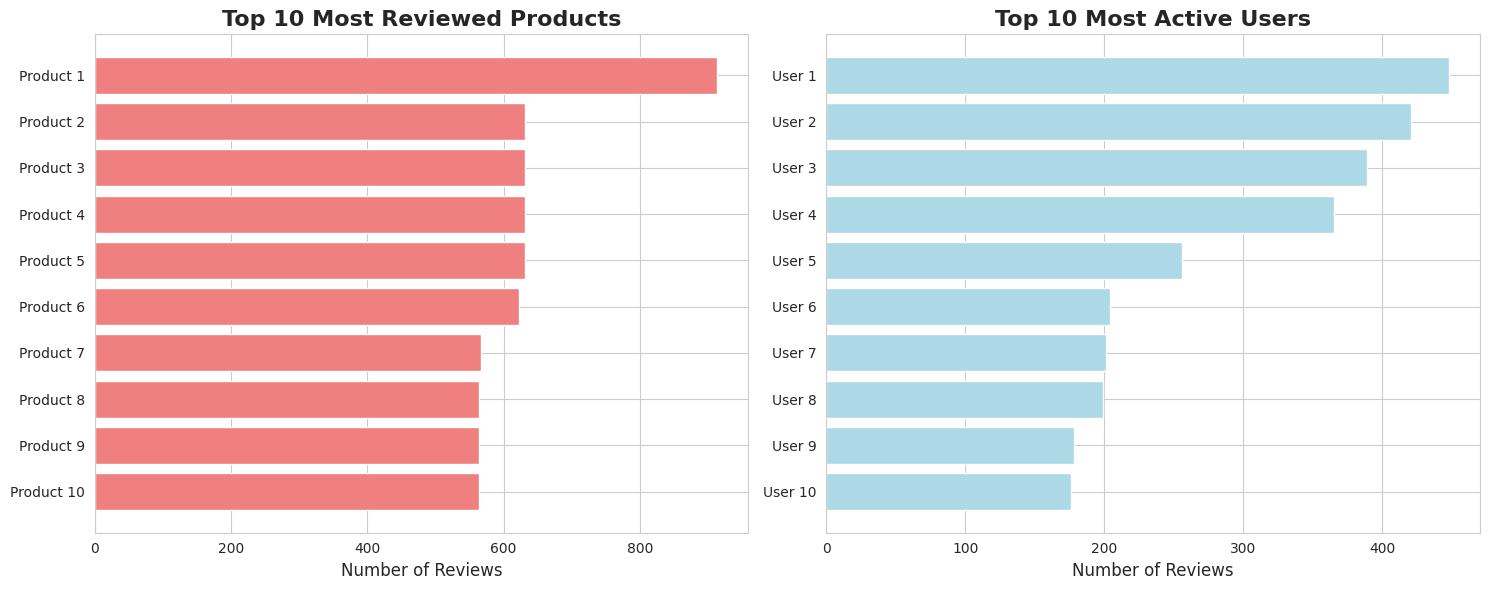


Most reviewed product has 913 reviews
Most active user wrote 448 reviews


In [11]:
# Top analysis
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Top 10 products
top_products = df['product/productId'].value_counts().head(10)
axes[0].barh(range(len(top_products)), top_products.values, color='lightcoral')
axes[0].set_yticks(range(len(top_products)))
axes[0].set_yticklabels([f"Product {i+1}" for i in range(len(top_products))])
axes[0].set_title('Top 10 Most Reviewed Products', fontsize=16, fontweight='bold')
axes[0].set_xlabel('Number of Reviews', fontsize=12)
axes[0].invert_yaxis()

# Top 10 users
top_users = df['review/userId'].value_counts().head(10)
axes[1].barh(range(len(top_users)), top_users.values, color='lightblue')
axes[1].set_yticks(range(len(top_users)))
axes[1].set_yticklabels([f"User {i+1}" for i in range(len(top_users))])
axes[1].set_title('Top 10 Most Active Users', fontsize=16, fontweight='bold')
axes[1].set_xlabel('Number of Reviews', fontsize=12)
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

print(f"\nMost reviewed product has {top_products.values[0]} reviews")
print(f"Most active user wrote {top_users.values[0]} reviews")

### Helpfulness Analysis

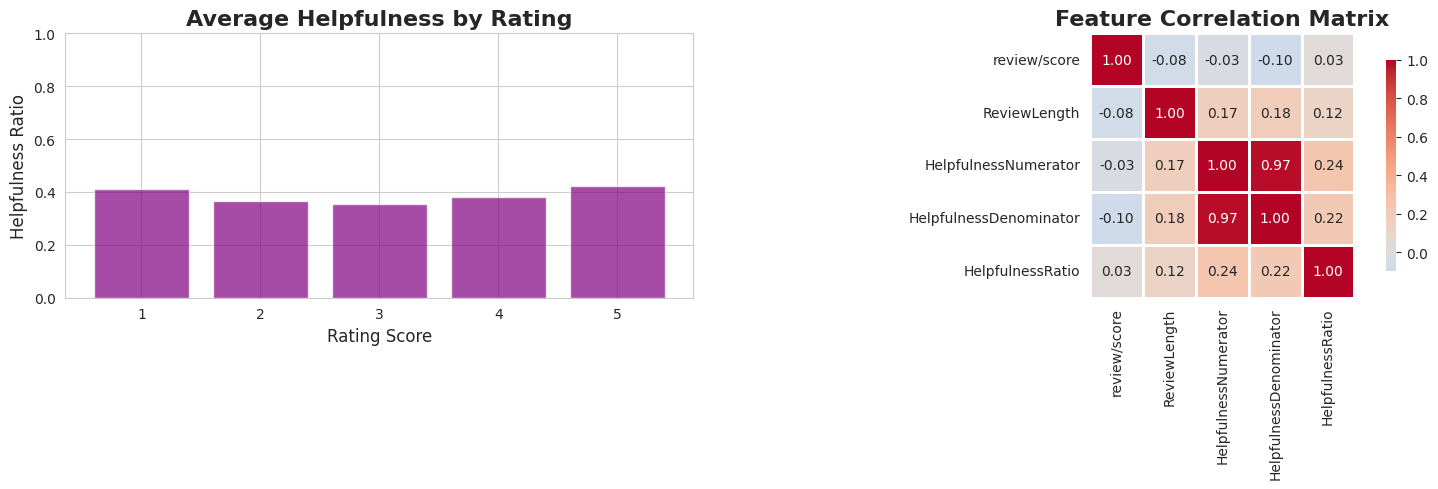

In [12]:
# Parse helpfulness ratio
df[['HelpfulnessNumerator', 'HelpfulnessDenominator']] = df['review/helpfulness'].str.split('/', expand=True)
df['HelpfulnessNumerator'] = pd.to_numeric(df['HelpfulnessNumerator'], errors='coerce')
df['HelpfulnessDenominator'] = pd.to_numeric(df['HelpfulnessDenominator'], errors='coerce')
df['HelpfulnessRatio'] = df['HelpfulnessNumerator'] / df['HelpfulnessDenominator'].replace(0, 1)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Helpfulness by rating
helpfulness_by_rating = df.groupby('review/score')['HelpfulnessRatio'].mean()
axes[0].bar(helpfulness_by_rating.index, helpfulness_by_rating.values, color='purple', alpha=0.7)
axes[0].set_title('Average Helpfulness by Rating', fontsize=16, fontweight='bold')
axes[0].set_xlabel('Rating Score', fontsize=12)
axes[0].set_ylabel('Helpfulness Ratio', fontsize=12)
axes[0].set_ylim(0, 1)

# Correlation heatmap
corr_data = df[['review/score', 'ReviewLength', 'HelpfulnessNumerator', 'HelpfulnessDenominator', 'HelpfulnessRatio']].corr()
sns.heatmap(corr_data, annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=axes[1], 
            square=True, linewidths=1, cbar_kws={"shrink": 0.8})
axes[1].set_title('Feature Correlation Matrix', fontsize=16, fontweight='bold')

plt.tight_layout()
plt.show()

### Summary Statistics

In [13]:
# Summary dashboard
print("="*60)
print("DATASET SUMMARY")
print("="*60)
print(f"\nTotal Reviews: {len(df):,}")
print(f"Total Products: {df['product/productId'].nunique():,}")
print(f"Total Users: {df['review/userId'].nunique():,}")
print(f"\nDate Range: {df['Date'].min().date()} to {df['Date'].max().date()}")
print(f"\nRating Distribution:")
print(df['review/score'].value_counts(normalize=True).sort_index().apply(lambda x: f"{x*100:.1f}%"))
print(f"\nAverage Rating: {df['review/score'].mean():.2f}")
print(f"Median Rating: {df['review/score'].median():.0f}")
print(f"\nAverage Review Length: {df['ReviewLength'].mean():.0f} characters")
print(f"Median Review Length: {df['ReviewLength'].median():.0f} characters")
print("="*60)

DATASET SUMMARY

Total Reviews: 568,461
Total Products: 74,258
Total Users: 256,059

Date Range: 1999-10-08 to 2012-10-26

Rating Distribution:
review/score
1.0     9.2%
2.0     5.2%
3.0     7.5%
4.0    14.2%
5.0    63.9%
Name: proportion, dtype: object

Average Rating: 4.18
Median Rating: 5

Average Review Length: 436 characters
Median Review Length: 302 characters


## Phase 4: Data Cleaning

In [14]:
# Check for missing values
print("Missing values per column:")
print(df.isnull().sum())
print(f"\nTotal missing values: {df.isnull().sum().sum()}")
print(f"\nPercentage of missing values:")
print((df.isnull().sum() / len(df) * 100).round(2))

Missing values per column:
product/productId         7
review/userId             7
review/profileName        7
review/helpfulness        7
review/score              7
review/time               7
review/summary            7
review/text               7
ReviewLength              0
Date                      7
Year                      7
Month                     7
HelpfulnessNumerator      7
HelpfulnessDenominator    7
HelpfulnessRatio          7
dtype: int64

Total missing values: 98

Percentage of missing values:
product/productId         0.0
review/userId             0.0
review/profileName        0.0
review/helpfulness        0.0
review/score              0.0
review/time               0.0
review/summary            0.0
review/text               0.0
ReviewLength              0.0
Date                      0.0
Year                      0.0
Month                     0.0
HelpfulnessNumerator      0.0
HelpfulnessDenominator    0.0
HelpfulnessRatio          0.0
dtype: float64


In [15]:
# Drop rows with missing values
df_clean = df.dropna()

print(f"Original dataset: {len(df):,} rows")
print(f"After cleaning: {len(df_clean):,} rows")
print(f"Rows removed: {len(df) - len(df_clean)}")
print(f"\nMissing values after cleaning:")
print(df_clean.isnull().sum().sum())

Original dataset: 568,461 rows
After cleaning: 568,447 rows
Rows removed: 14

Missing values after cleaning:
0


## Phase 5: Collaborative Filtering Model

In [16]:
from surprise import Dataset, Reader, SVD
from surprise.model_selection import train_test_split, cross_validate
from surprise import accuracy
import pickle

# Prepare data for Surprise library
# Need: user_id, product_id, rating
reader = Reader(rating_scale=(1, 5))
data = Dataset.load_from_df(df_clean[['review/userId', 'product/productId', 'review/score']], reader)

# Split into train/test (80/20)
trainset, testset = train_test_split(data, test_size=0.2, random_state=42)

print(f"Training set: {trainset.n_ratings:,} ratings")
print(f"Test set: {len(testset):,} ratings")
print(f"Number of users: {trainset.n_users:,}")
print(f"Number of products: {trainset.n_items:,}")

Training set: 454,757 ratings
Test set: 113,690 ratings
Number of users: 219,382
Number of products: 67,584


## Phase 6: Model Training

In [17]:
# Initialize SVD model
svd_model = SVD(n_factors=100, n_epochs=20, lr_all=0.005, reg_all=0.02, random_state=42)

print("Training SVD model...")
print("This may take 5-10 minutes...")

# Train the model
svd_model.fit(trainset)

print("\n✓ Model training complete!")

Training SVD model...
This may take 5-10 minutes...

✓ Model training complete!


## Phase 7: Model Evaluation

In [18]:
# Make predictions on test set
predictions = svd_model.test(testset)

# Calculate accuracy metrics
rmse = accuracy.rmse(predictions, verbose=False)
mae = accuracy.mae(predictions, verbose=False)

print("="*50)
print("MODEL EVALUATION")
print("="*50)
print(f"RMSE (Root Mean Square Error): {rmse:.4f}")
print(f"MAE (Mean Absolute Error): {mae:.4f}")
print("\nInterpretation:")
print(f"On average, predictions are off by {mae:.2f} stars")
print("="*50)

MODEL EVALUATION
RMSE (Root Mean Square Error): 1.0845
MAE (Mean Absolute Error): 0.7895

Interpretation:
On average, predictions are off by 0.79 stars


### Saving model

In [19]:
# Create models directory
os.makedirs(os.path.expanduser('~/Desktop/Hireable/models/'), exist_ok=True)

# Save the trained model
model_path = os.path.expanduser('~/Desktop/Hireable/models/collab_filter.pkl')
with open(model_path, 'wb') as f:
    pickle.dump(svd_model, f)

print(f"✓ Model saved to: {model_path}")

✓ Model saved to: /home/jami/Desktop/Hireable/models/collab_filter.pkl


### Testing the model

In [20]:
# Test predictions for a sample user
sample_user = df_clean['review/userId'].iloc[0]
sample_product = df_clean['product/productId'].iloc[100]

# Predict rating
prediction = svd_model.predict(sample_user, sample_product)

print("SAMPLE PREDICTION TEST")
print("="*50)
print(f"User ID: {sample_user}")
print(f"Product ID: {sample_product}")
print(f"Predicted Rating: {prediction.est:.2f} stars")
print("="*50)

SAMPLE PREDICTION TEST
User ID: A3SGXH7AUHU8GW
Product ID: B004K2IHUO
Predicted Rating: 4.29 stars


## Phase 8: BERT Sentiment Analysis

In [21]:
import torch

# Check CUDA availability
print("="*50)
print("SYSTEM CHECK")
print("="*50)
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")

if torch.cuda.is_available():
    print(f"CUDA version: {torch.version.cuda}")
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    device = torch.device("cuda")
    print(f"✓ Using GPU for training")
else:
    device = torch.device("cpu")
    print(f"⚠ Using CPU for training (will be slow)")
    
print(f"\nDevice selected: {device}")
print("="*50)

SYSTEM CHECK
PyTorch version: 2.6.0+cu124
CUDA available: True
CUDA version: 12.4
GPU: NVIDIA GeForce GTX 1660 SUPER
✓ Using GPU for training

Device selected: cuda


In [22]:
from transformers import DistilBertTokenizer
import numpy as np

# Initialize tokenizer
print("Loading tokenizer...")
tokenizer = DistilBertTokenizer.from_pretrained('distilbert-base-uncased')

# Prepare texts and labels (FULL DATASET)
texts = df_clean['review/text'].tolist()
labels = df_clean['review/score'].astype(int).tolist()

# Convert ratings 1-5 to 0-4 for model (model expects 0-indexed classes)
labels = [l - 1 for l in labels]

print(f"Total samples: {len(texts):,}")
print(f"Label distribution: {np.bincount(labels)}")
print("✓ Data prepared for BERT training")


Loading tokenizer...


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

Total samples: 568,447
Label distribution: [ 52268  29768  42639  80654 363118]
✓ Data prepared for BERT training


### preparing data for bert

In [23]:
from sklearn.model_selection import train_test_split

# Split data: 80% train, 20% test
train_texts, test_texts, train_labels, test_labels = train_test_split(
    texts, labels, test_size=0.2, random_state=42, stratify=labels
)

print(f"Training samples: {len(train_texts):,}")
print(f"Test samples: {len(test_texts):,}")
print("\nTrain label distribution:", np.bincount(train_labels))
print("Test label distribution:", np.bincount(test_labels))

Training samples: 454,757
Test samples: 113,690

Train label distribution: [ 41814  23815  34111  64523 290494]
Test label distribution: [10454  5953  8528 16131 72624]


In [24]:
print("Tokenizing training data...")
train_encodings = tokenizer(train_texts, truncation=True, padding=True, max_length=128)

print("Tokenizing test data...")
test_encodings = tokenizer(test_texts, truncation=True, padding=True, max_length=128)

print("✓ Tokenization complete!")

Tokenizing training data...
Tokenizing test data...
✓ Tokenization complete!


In [25]:
import torch
from torch.utils.data import Dataset, DataLoader

class ReviewDataset(Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx])
        return item

    def __len__(self):
        return len(self.labels)

# Create datasets
train_dataset = ReviewDataset(train_encodings, train_labels)
test_dataset = ReviewDataset(test_encodings, test_labels)

# Create data loaders
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=16)

print(f"✓ Datasets created")
print(f"Training batches: {len(train_loader):,}")
print(f"Test batches: {len(test_loader):,}")

✓ Datasets created
Training batches: 28,423
Test batches: 7,106


In [26]:
from transformers import DistilBertForSequenceClassification

# Load pre-trained DistilBERT for 5-class classification
model = DistilBertForSequenceClassification.from_pretrained('distilbert-base-uncased', num_labels=5)
model.to(device)

print(f"✓ Model loaded and moved to {device}")
print(f"Model parameters: {sum(p.numel() for p in model.parameters()):,}")

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


✓ Model loaded and moved to cuda
Model parameters: 66,957,317


In [27]:
from torch.optim import AdamW
from tqdm.auto import tqdm

# Optimizer
optimizer = AdamW(model.parameters(), lr=5e-5)

# Training parameters
num_epochs = 3  # 3 epochs is standard for BERT fine-tuning

print("Training configuration:")
print(f"Epochs: {num_epochs}")
print(f"Batch size: 16")
print(f"Learning rate: 5e-5")
print(f"Device: {device}")

Training configuration:
Epochs: 3
Batch size: 16
Learning rate: 5e-5
Device: cuda


#### model training

In [28]:
print("\n" + "="*50)
print("STARTING TRAINING")
print("="*50)

model.train()
for epoch in range(num_epochs):
    print(f"\nEpoch {epoch + 1}/{num_epochs}")
    
    total_loss = 0
    progress_bar = tqdm(train_loader, desc=f"Training Epoch {epoch+1}")
    
    for batch in progress_bar:
        # Move batch to device
        batch = {k: v.to(device) for k, v in batch.items()}
        
        # Forward pass
        outputs = model(**batch)
        loss = outputs.loss
        
        # Backward pass
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()
        
        total_loss += loss.item()
        progress_bar.set_postfix({'loss': loss.item()})
    
    avg_loss = total_loss / len(train_loader)
    print(f"Average loss: {avg_loss:.4f}")

print("\n✓ Training complete!")


STARTING TRAINING

Epoch 1/3


Training Epoch 1:   0%|          | 0/28423 [00:00<?, ?it/s]

Average loss: 0.6232

Epoch 2/3


Training Epoch 2:   0%|          | 0/28423 [00:00<?, ?it/s]

Average loss: 0.5079

Epoch 3/3


Training Epoch 3:   0%|          | 0/28423 [00:00<?, ?it/s]

Average loss: 0.4294

✓ Training complete!


### Save Model & Training State:

In [29]:
import pickle

# Create models directory
os.makedirs(os.path.expanduser('~/Desktop/Hireable/models/sentiment_bert/'), exist_ok=True)

# Save model and tokenizer (Hugging Face format)
model_save_path = os.path.expanduser('~/Desktop/Hireable/models/sentiment_bert/')
model.save_pretrained(model_save_path)
tokenizer.save_pretrained(model_save_path)

# Save training state (for resuming training later)
checkpoint = {
    'epoch': num_epochs,
    'model_state_dict': model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'device': str(device)
}

checkpoint_path = os.path.expanduser('~/Desktop/Hireable/models/sentiment_bert_checkpoint.pkl')
with open(checkpoint_path, 'wb') as f:
    pickle.dump(checkpoint, f)

print("="*50)
print("MODEL SAVED")
print("="*50)
print(f"✓ Model saved to: {model_save_path}")
print(f"✓ Checkpoint saved to: {checkpoint_path}")
print("\nSaved files:")
print("  - config.json (model configuration)")
print("  - pytorch_model.bin (model weights)")
print("  - tokenizer files")
print("  - checkpoint.pkl (for resuming training)")
print("="*50)

MODEL SAVED
✓ Model saved to: /home/jami/Desktop/Hireable/models/sentiment_bert/
✓ Checkpoint saved to: /home/jami/Desktop/Hireable/models/sentiment_bert_checkpoint.pkl

Saved files:
  - config.json (model configuration)
  - pytorch_model.bin (model weights)
  - tokenizer files
  - checkpoint.pkl (for resuming training)


### Model Evaluation

#### Evaluate on Test Set

In [31]:
from sklearn.metrics import accuracy_score, f1_score, classification_report
import numpy as np

print("="*50)
print("EVALUATING MODEL ON TEST SET")
print("="*50)

model.eval()  # Set to evaluation mode
predictions = []
true_labels = []

print("Making predictions on test set...")
progress_bar = tqdm(test_loader, desc="Evaluating")

with torch.no_grad():  # No gradient computation
    for batch in progress_bar:
        # Move batch to device
        batch = {k: v.to(device) for k, v in batch.items()}
        
        # Forward pass
        outputs = model(**batch)
        logits = outputs.logits
        
        # Get predictions
        preds = torch.argmax(logits, dim=-1)
        
        predictions.extend(preds.cpu().numpy())
        true_labels.extend(batch['labels'].cpu().numpy())

# Convert to numpy arrays
predictions = np.array(predictions)
true_labels = np.array(true_labels)

print("\n✓ Evaluation complete!")

EVALUATING MODEL ON TEST SET
Making predictions on test set...


Evaluating:   0%|          | 0/7106 [00:00<?, ?it/s]


✓ Evaluation complete!


#### Calculate Metrics

In [32]:
# Calculate metrics
accuracy = accuracy_score(true_labels, predictions)
f1_macro = f1_score(true_labels, predictions, average='macro')
f1_weighted = f1_score(true_labels, predictions, average='weighted')

print("="*50)
print("MODEL PERFORMANCE METRICS")
print("="*50)
print(f"Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"F1 Score (Macro): {f1_macro:.4f}")
print(f"F1 Score (Weighted): {f1_weighted:.4f}")
print("="*50)

# Detailed classification report
print("\nDetailed Classification Report:")
print("="*50)
class_names = ['1 Star', '2 Stars', '3 Stars', '4 Stars', '5 Stars']
print(classification_report(true_labels, predictions, target_names=class_names, digits=4))

MODEL PERFORMANCE METRICS
Accuracy: 0.8257 (82.57%)
F1 Score (Macro): 0.6790
F1 Score (Weighted): 0.8163

Detailed Classification Report:
              precision    recall  f1-score   support

      1 Star     0.7439    0.8255    0.7826     10454
     2 Stars     0.6210    0.4164    0.4985      5953
     3 Stars     0.6213    0.5882    0.6043      8528
     4 Stars     0.6802    0.5148    0.5861     16131
     5 Stars     0.8925    0.9563    0.9233     72624

    accuracy                         0.8257    113690
   macro avg     0.7118    0.6602    0.6790    113690
weighted avg     0.8141    0.8257    0.8163    113690



#### Confusion Matrix Visualization:

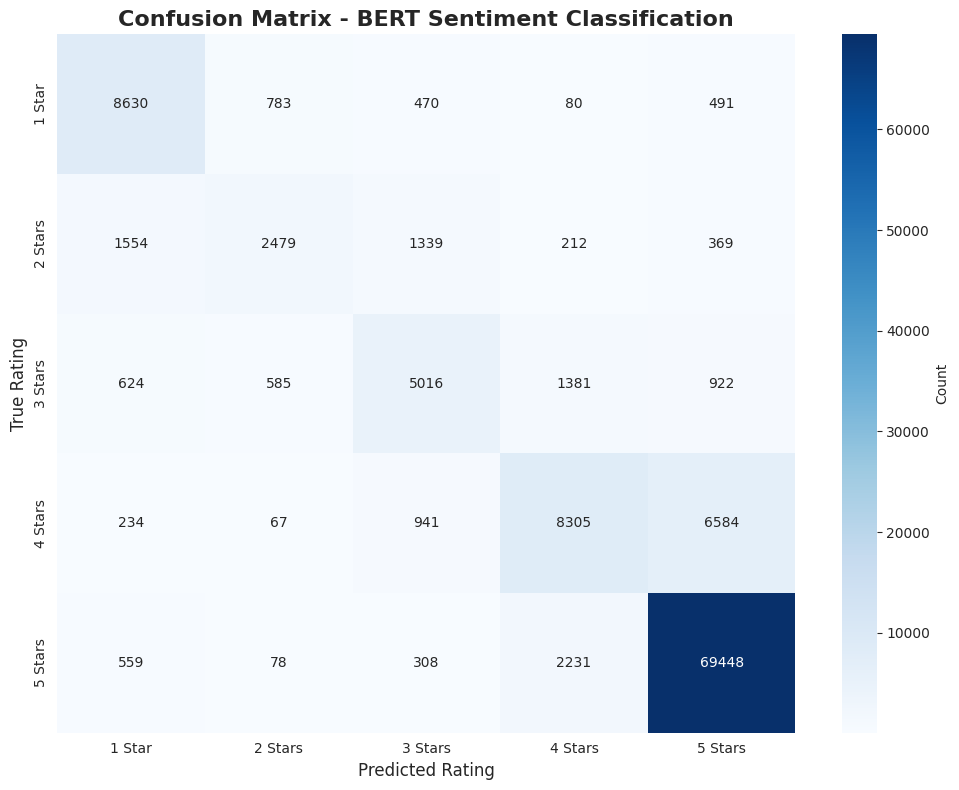


Per-Class Accuracy:
1 Star: 0.8255 (82.55%)
2 Stars: 0.4164 (41.64%)
3 Stars: 0.5882 (58.82%)
4 Stars: 0.5148 (51.48%)
5 Stars: 0.9563 (95.63%)


In [33]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Calculate confusion matrix
cm = confusion_matrix(true_labels, predictions)

# Plot confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, yticklabels=class_names,
            cbar_kws={'label': 'Count'})
plt.title('Confusion Matrix - BERT Sentiment Classification', fontsize=16, fontweight='bold')
plt.xlabel('Predicted Rating', fontsize=12)
plt.ylabel('True Rating', fontsize=12)
plt.tight_layout()
plt.show()

# Calculate per-class accuracy
print("\nPer-Class Accuracy:")
print("="*50)
for i, class_name in enumerate(class_names):
    class_accuracy = cm[i, i] / cm[i].sum()
    print(f"{class_name}: {class_accuracy:.4f} ({class_accuracy*100:.2f}%)")

#### Prediction Distribution

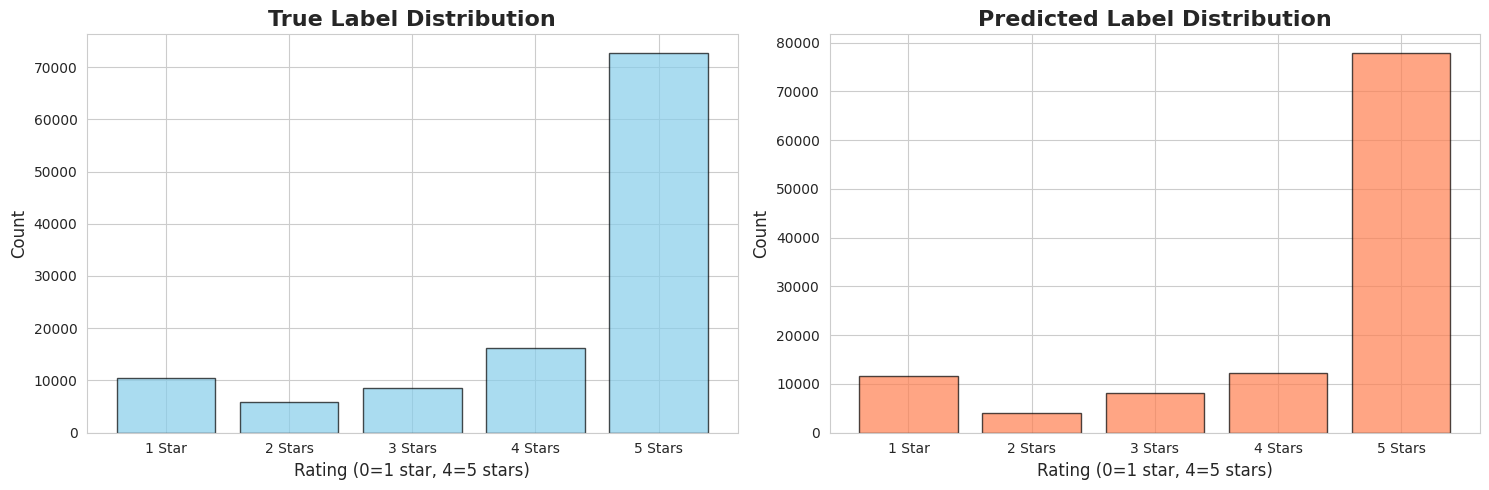

In [34]:
# Compare true vs predicted distributions
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# True distribution
axes[0].bar(range(5), np.bincount(true_labels), color='skyblue', alpha=0.7, edgecolor='black')
axes[0].set_title('True Label Distribution', fontsize=16, fontweight='bold')
axes[0].set_xlabel('Rating (0=1 star, 4=5 stars)', fontsize=12)
axes[0].set_ylabel('Count', fontsize=12)
axes[0].set_xticks(range(5))
axes[0].set_xticklabels(class_names)

# Predicted distribution
axes[1].bar(range(5), np.bincount(predictions), color='coral', alpha=0.7, edgecolor='black')
axes[1].set_title('Predicted Label Distribution', fontsize=16, fontweight='bold')
axes[1].set_xlabel('Rating (0=1 star, 4=5 stars)', fontsize=12)
axes[1].set_ylabel('Count', fontsize=12)
axes[1].set_xticks(range(5))
axes[1].set_xticklabels(class_names)

plt.tight_layout()
plt.show()

#### Sample Predictions (Qualitative Check)

In [35]:
# Show some sample predictions
print("="*50)
print("SAMPLE PREDICTIONS")
print("="*50)

sample_indices = np.random.choice(len(test_texts), 5, replace=False)

for idx in sample_indices:
    text = test_texts[idx][:200]  # First 200 chars
    true_label = test_labels[idx] + 1  # Convert back to 1-5
    pred_label = predictions[idx] + 1  # Convert back to 1-5
    
    print(f"\nReview: {text}...")
    print(f"True Rating: {true_label} stars")
    print(f"Predicted Rating: {pred_label} stars")
    print(f"Correct: {'✓' if true_label == pred_label else '✗'}")
    print("-"*50)

SAMPLE PREDICTIONS

Review: I can't stand the smell of this treat.  They are very bite-sized (tiny little beads).  I wouldn't mind them so much if they smelled a little better.  As it stands I can't be near the opened bag withou...
True Rating: 3 stars
Predicted Rating: 3 stars
Correct: ✓
--------------------------------------------------

Review: I have been using Yogourmet for over 40 years and<br /> I can't find anything that can beat it?????<br /><br /> This a quality product???...
True Rating: 5 stars
Predicted Rating: 5 stars
Correct: ✓
--------------------------------------------------

Review: I accidentally bought these chips (thought I was getting original pop chips), but have to say, because they are a little tart, I don't seem to be eating them as quickly, (good for my diet!).  If you l...
True Rating: 3 stars
Predicted Rating: 3 stars
Correct: ✓
--------------------------------------------------

Review: These gravy packages from Knorr® are terrific, and perfect for non-ch

#### Save Evaluation Results

In [36]:
# Create results directory
os.makedirs(os.path.expanduser('~/Desktop/Hireable/results/'), exist_ok=True)

# Save metrics
results = {
    'accuracy': accuracy,
    'f1_macro': f1_macro,
    'f1_weighted': f1_weighted,
    'confusion_matrix': cm.tolist(),
    'predictions': predictions.tolist(),
    'true_labels': true_labels.tolist()
}

results_path = os.path.expanduser('~/Desktop/Hireable/results/bert_evaluation.pkl')
with open(results_path, 'wb') as f:
    pickle.dump(results, f)

# Save confusion matrix plot
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix - BERT Sentiment Classification', fontsize=16, fontweight='bold')
plt.xlabel('Predicted Rating', fontsize=12)
plt.ylabel('True Rating', fontsize=12)
plt.tight_layout()
plot_path = os.path.expanduser('~/Desktop/Hireable/results/confusion_matrix.png')
plt.savefig(plot_path, dpi=300, bbox_inches='tight')
plt.close()

print("="*50)
print("EVALUATION RESULTS SAVED")
print("="*50)
print(f"✓ Metrics saved to: {results_path}")
print(f"✓ Confusion matrix saved to: {plot_path}")
print("="*50)

EVALUATION RESULTS SAVED
✓ Metrics saved to: /home/jami/Desktop/Hireable/results/bert_evaluation.pkl
✓ Confusion matrix saved to: /home/jami/Desktop/Hireable/results/confusion_matrix.png


## Phase 9: Hybrid Recommendations

#### Load Both Models

In [37]:
print("="*50)
print("LOADING MODELS FOR HYBRID SYSTEM")
print("="*50)

# Load SVD model
with open(os.path.expanduser('~/Desktop/Hireable/models/collab_filter.pkl'), 'rb') as f:
    svd_model = pickle.load(f)
print("✓ SVD model loaded")

# Load BERT model
bert_model = DistilBertForSequenceClassification.from_pretrained(
    os.path.expanduser('~/Desktop/Hireable/models/sentiment_bert/')
)
bert_tokenizer = DistilBertTokenizer.from_pretrained(
    os.path.expanduser('~/Desktop/Hireable/models/sentiment_bert/')
)
bert_model.to(device)
bert_model.eval()
print("✓ BERT model loaded")
print("="*50)

LOADING MODELS FOR HYBRID SYSTEM
✓ SVD model loaded
✓ BERT model loaded


### Get Product Sentiment Scores:

In [39]:
def get_product_sentiment(product_id, df, model, tokenizer, device):
    """
    Get average sentiment score for a product based on its reviews
    """
    # Get all reviews for this product
    product_reviews = df[df['product/productId'] == product_id]['review/text'].tolist()
    
    if len(product_reviews) == 0:
        return 3.0  # Default neutral score if no reviews
    
    # Limit to 10 most recent reviews for speed
    product_reviews = product_reviews[:10]
    
    # Tokenize
    encodings = tokenizer(product_reviews, truncation=True, padding=True, 
                         max_length=128, return_tensors='pt')
    encodings = {k: v.to(device) for k, v in encodings.items()}
    
    # Get predictions
    with torch.no_grad():
        outputs = model(**encodings)
        predictions = torch.argmax(outputs.logits, dim=-1)
    
    # Convert 0-4 back to 1-5 and get average
    sentiment_scores = predictions.cpu().numpy() + 1
    avg_sentiment = sentiment_scores.mean()
    
    return avg_sentiment

print("✓ Sentiment scoring function created")

✓ Sentiment scoring function created


#### Hybrid Recommendation Function

In [40]:
def hybrid_recommend(user_id, df, svd_model, bert_model, tokenizer, device, n_recommendations=10):
    """
    Generate hybrid recommendations combining CF and sentiment
    """
    print(f"\nGenerating recommendations for user: {user_id}")
    
    # Get all products
    all_products = df['product/productId'].unique()
    
    # Get products user hasn't reviewed
    user_products = df[df['review/userId'] == user_id]['product/productId'].unique()
    candidate_products = [p for p in all_products if p not in user_products]
    
    print(f"Candidate products: {len(candidate_products):,}")
    
    # Get CF predictions for all candidates
    print("Getting collaborative filtering scores...")
    cf_scores = {}
    for product in candidate_products[:1000]:  # Limit to 1000 for speed
        pred = svd_model.predict(user_id, product)
        cf_scores[product] = pred.est
    
    # Get top 50 from CF
    top_cf = sorted(cf_scores.items(), key=lambda x: x[1], reverse=True)[:50]
    
    print(f"Top {len(top_cf)} products from CF, getting sentiment scores...")
    
    # Get sentiment scores for top CF products
    hybrid_scores = []
    for product, cf_score in top_cf:
        sentiment_score = get_product_sentiment(product, df, bert_model, tokenizer, device)
        
        # Hybrid score: 70% CF + 30% sentiment (normalized to 1-5 scale)
        hybrid_score = (0.7 * cf_score) + (0.3 * sentiment_score)
        
        hybrid_scores.append({
            'product_id': product,
            'cf_score': cf_score,
            'sentiment_score': sentiment_score,
            'hybrid_score': hybrid_score
        })
    
    # Sort by hybrid score
    hybrid_scores = sorted(hybrid_scores, key=lambda x: x['hybrid_score'], reverse=True)
    
    return hybrid_scores[:n_recommendations]

print("✓ Hybrid recommendation function created")

✓ Hybrid recommendation function created


#### Test Hybrid Recommendations

In [41]:
# Test with a sample user
sample_user = df_clean['review/userId'].iloc[100]

print("="*50)
print("TESTING HYBRID RECOMMENDATION SYSTEM")
print("="*50)

recommendations = hybrid_recommend(
    user_id=sample_user,
    df=df_clean,
    svd_model=svd_model,
    bert_model=bert_model,
    tokenizer=bert_tokenizer,
    device=device,
    n_recommendations=10
)

print("\n" + "="*50)
print("TOP 10 RECOMMENDATIONS")
print("="*50)

for i, rec in enumerate(recommendations, 1):
    print(f"\n{i}. Product: {rec['product_id']}")
    print(f"   CF Score: {rec['cf_score']:.2f}")
    print(f"   Sentiment Score: {rec['sentiment_score']:.2f}")
    print(f"   Hybrid Score: {rec['hybrid_score']:.2f}")

TESTING HYBRID RECOMMENDATION SYSTEM

Generating recommendations for user: A1SYSKR79LA2CB
Candidate products: 74,245
Getting collaborative filtering scores...
Top 50 products from CF, getting sentiment scores...

TOP 10 RECOMMENDATIONS

1. Product: B000E1HVW0
   CF Score: 4.73
   Sentiment Score: 5.00
   Hybrid Score: 4.81

2. Product: B000H23YC2
   CF Score: 4.60
   Sentiment Score: 5.00
   Hybrid Score: 4.72

3. Product: B000X2CWTM
   CF Score: 4.59
   Sentiment Score: 5.00
   Hybrid Score: 4.72

4. Product: B003KLSZGW
   CF Score: 4.55
   Sentiment Score: 4.90
   Hybrid Score: 4.65

5. Product: B001L1DYAA
   CF Score: 4.55
   Sentiment Score: 4.80
   Hybrid Score: 4.62

6. Product: B001L1KH6Y
   CF Score: 4.46
   Sentiment Score: 5.00
   Hybrid Score: 4.62

7. Product: B002BCD2OG
   CF Score: 4.53
   Sentiment Score: 4.80
   Hybrid Score: 4.61

8. Product: B005FG6KZ8
   CF Score: 4.45
   Sentiment Score: 5.00
   Hybrid Score: 4.61

9. Product: B0028VAQSU
   CF Score: 4.60
   Sentime

#### Save Recommendations

In [42]:
# Save sample recommendations
recommendations_df = pd.DataFrame(recommendations)
rec_path = os.path.expanduser('~/Desktop/Hireable/results/sample_recommendations.csv')
recommendations_df.to_csv(rec_path, index=False)

print(f"\n✓ Recommendations saved to: {rec_path}")


✓ Recommendations saved to: /home/jami/Desktop/Hireable/results/sample_recommendations.csv


## Phase 10: Final Results

#### Generate Recommendations from All 3 Methods

In [43]:
# Generate recommendations using all 3 methods for comparison
print("="*50)
print("GENERATING RECOMMENDATIONS - ALL METHODS")
print("="*50)

sample_user = df_clean['review/userId'].iloc[100]

# Method 1: CF-only
print("\n1. Collaborative Filtering only...")
cf_only = []
all_products = df_clean['product/productId'].unique()
user_products = df_clean[df_clean['review/userId'] == sample_user]['product/productId'].unique()
candidate_products = [p for p in all_products if p not in user_products]

for product in candidate_products[:1000]:
    pred = svd_model.predict(sample_user, product)
    cf_only.append({'product_id': product, 'score': pred.est})

cf_only = sorted(cf_only, key=lambda x: x['score'], reverse=True)[:10]

# Method 2: Sentiment-only
print("2. BERT Sentiment only...")
sentiment_only = []

for product in candidate_products[:1000]:
    sentiment_score = get_product_sentiment(product, df_clean, bert_model, bert_tokenizer, device)
    sentiment_only.append({'product_id': product, 'score': sentiment_score})

sentiment_only = sorted(sentiment_only, key=lambda x: x['score'], reverse=True)[:10]

# Method 3: Hybrid (already have from previous cell)
print("3. Hybrid system...")
hybrid_recs = recommendations  # From previous cell

print("\n✓ All methods complete!")

GENERATING RECOMMENDATIONS - ALL METHODS

1. Collaborative Filtering only...
2. BERT Sentiment only...
3. Hybrid system...

✓ All methods complete!


#### Score Comparison Chart

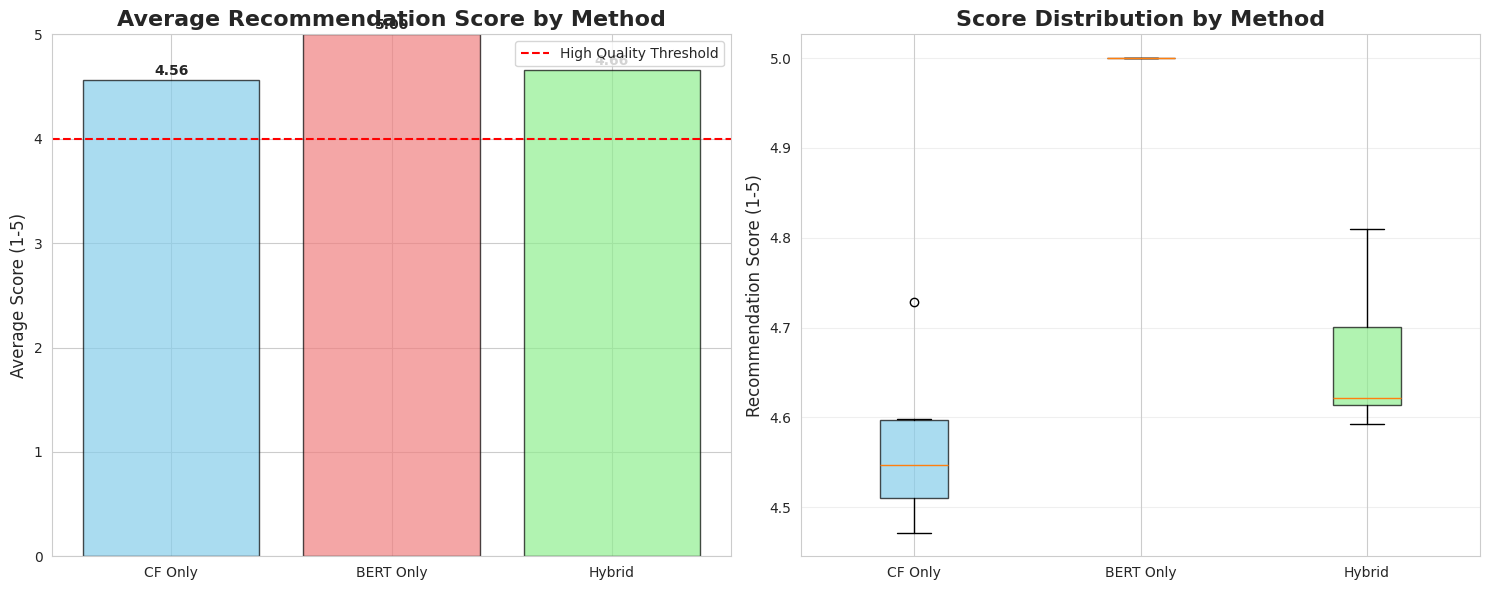

In [47]:
# Compare average scores
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Average scores
methods = ['CF Only', 'BERT Only', 'Hybrid']
avg_scores = [
    np.mean([r['score'] for r in cf_only]),
    np.mean([r['score'] for r in sentiment_only]),
    np.mean([r['hybrid_score'] for r in hybrid_recs])
]

colors = ['skyblue', 'lightcoral', 'lightgreen']
axes[0].bar(methods, avg_scores, color=colors, edgecolor='black', alpha=0.7)
axes[0].set_title('Average Recommendation Score by Method', fontsize=16, fontweight='bold')
axes[0].set_ylabel('Average Score (1-5)', fontsize=12)
axes[0].set_ylim(0, 5)
axes[0].axhline(y=4.0, color='red', linestyle='--', label='High Quality Threshold')
axes[0].legend()

# Add value labels on bars
for i, v in enumerate(avg_scores):
    axes[0].text(i, v + 0.05, f'{v:.2f}', ha='center', fontweight='bold')

# Score ranges (min-max)
cf_scores = [r['score'] for r in cf_only]
sent_scores = [r['score'] for r in sentiment_only]
hybrid_scores = [r['hybrid_score'] for r in hybrid_recs]

data_to_plot = [cf_scores, sent_scores, hybrid_scores]
bp = axes[1].boxplot(data_to_plot, labels=methods, patch_artist=True)

# Color boxes
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

axes[1].set_title('Score Distribution by Method', fontsize=16, fontweight='bold')
axes[1].set_ylabel('Recommendation Score (1-5)', fontsize=12)
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

#### Recommendation Overlap Analysis

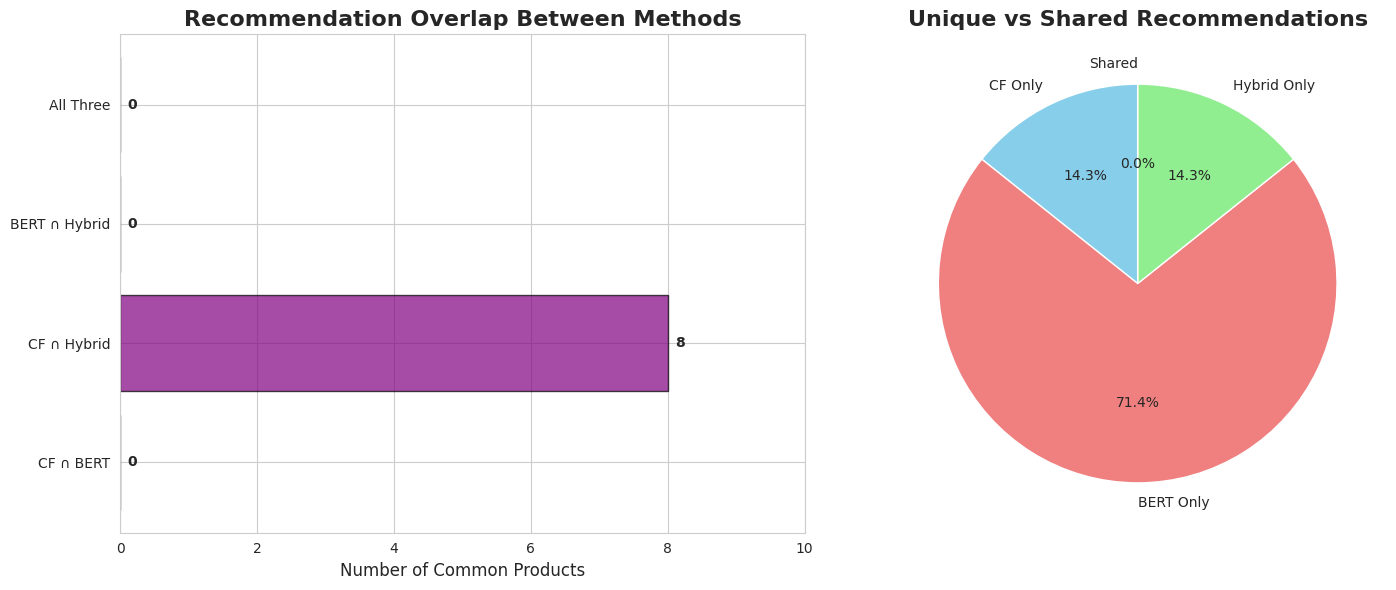


Overlap Analysis:
CF and BERT common: 0/10
CF and Hybrid common: 8/10
BERT and Hybrid common: 0/10
All three methods agree: 0/10


In [48]:
# Check overlap between methods
cf_products = set([r['product_id'] for r in cf_only])
sent_products = set([r['product_id'] for r in sentiment_only])
hybrid_products = set([r['product_id'] for r in hybrid_recs])

# Calculate overlaps
cf_sent_overlap = len(cf_products & sent_products)
cf_hybrid_overlap = len(cf_products & hybrid_products)
sent_hybrid_overlap = len(sent_products & hybrid_products)
all_three_overlap = len(cf_products & sent_products & hybrid_products)

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Overlap counts
overlap_data = {
    'CF ∩ BERT': cf_sent_overlap,
    'CF ∩ Hybrid': cf_hybrid_overlap,
    'BERT ∩ Hybrid': sent_hybrid_overlap,
    'All Three': all_three_overlap
}

axes[0].barh(list(overlap_data.keys()), list(overlap_data.values()), 
             color='purple', alpha=0.7, edgecolor='black')
axes[0].set_title('Recommendation Overlap Between Methods', fontsize=16, fontweight='bold')
axes[0].set_xlabel('Number of Common Products', fontsize=12)
axes[0].set_xlim(0, 10)

# Add value labels
for i, v in enumerate(overlap_data.values()):
    axes[0].text(v + 0.1, i, str(v), va='center', fontweight='bold')

# Unique recommendations
unique_cf = len(cf_products - sent_products - hybrid_products)
unique_sent = len(sent_products - cf_products - hybrid_products)
unique_hybrid = len(hybrid_products - cf_products - sent_products)

unique_data = {
    'CF Only': unique_cf,
    'BERT Only': unique_sent,
    'Hybrid Only': unique_hybrid,
    'Shared': all_three_overlap
}

colors_unique = ['skyblue', 'lightcoral', 'lightgreen', 'gold']
axes[1].pie(unique_data.values(), labels=unique_data.keys(), autopct='%1.1f%%',
            colors=colors_unique, startangle=90)
axes[1].set_title('Unique vs Shared Recommendations', fontsize=16, fontweight='bold')

plt.tight_layout()
plt.show()

print("\nOverlap Analysis:")
print("="*50)
print(f"CF and BERT common: {cf_sent_overlap}/10")
print(f"CF and Hybrid common: {cf_hybrid_overlap}/10")
print(f"BERT and Hybrid common: {sent_hybrid_overlap}/10")
print(f"All three methods agree: {all_three_overlap}/10")
print("="*50)

#### Side-by-Side Recommendations Table

In [49]:
# Create comparison table
print("="*70)
print("TOP 10 RECOMMENDATIONS - SIDE BY SIDE COMPARISON")
print("="*70)
print(f"{'Rank':<6}{'CF Only':<15}{'Score':<8}{'BERT Only':<15}{'Score':<8}{'Hybrid':<15}{'Score':<8}")
print("="*70)

for i in range(10):
    cf_prod = cf_only[i]['product_id'][:12]
    cf_score = cf_only[i]['score']
    
    sent_prod = sentiment_only[i]['product_id'][:12]
    sent_score = sentiment_only[i]['score']
    
    hyb_prod = hybrid_recs[i]['product_id'][:12]
    hyb_score = hybrid_recs[i]['hybrid_score']
    
    print(f"{i+1:<6}{cf_prod:<15}{cf_score:<8.2f}{sent_prod:<15}{sent_score:<8.2f}{hyb_prod:<15}{hyb_score:<8.2f}")

print("="*70)

TOP 10 RECOMMENDATIONS - SIDE BY SIDE COMPARISON
Rank  CF Only        Score   BERT Only      Score   Hybrid         Score   
1     B000E1HVW0     4.73    B001E4KFG0     5.00    B000E1HVW0     4.81    
2     B0028VAQSU     4.60    B000LQOCH0     5.00    B000H23YC2     4.72    
3     B000H23YC2     4.60    B000E7L2R4     5.00    B000X2CWTM     4.72    
4     B000X2CWTM     4.59    B00171APVA     5.00    B003KLSZGW     4.65    
5     B003KLSZGW     4.55    B0001PB9FE     5.00    B001L1DYAA     4.62    
6     B001L1DYAA     4.55    B001GVISJM     5.00    B001L1KH6Y     4.62    
7     B002BCD2OG     4.53    B00144C10S     5.00    B002BCD2OG     4.61    
8     B001E5E29A     4.50    B0001PB9FY     5.00    B005FG6KZ8     4.61    
9     B004K051VE     4.50    B003F6UO7K     5.00    B0028VAQSU     4.60    
10    B001EU5S9S     4.47    B002GWHC0G     5.00    B001EU5S9S     4.59    


#### Save Comparison Results

In [50]:
# Save comparison results
comparison_results = {
    'cf_only': cf_only,
    'sentiment_only': sentiment_only,
    'hybrid': hybrid_recs,
    'overlap_analysis': {
        'cf_sent_overlap': cf_sent_overlap,
        'cf_hybrid_overlap': cf_hybrid_overlap,
        'sent_hybrid_overlap': sent_hybrid_overlap,
        'all_three_overlap': all_three_overlap
    },
    'avg_scores': {
        'cf_avg': avg_scores[0],
        'sentiment_avg': avg_scores[1],
        'hybrid_avg': avg_scores[2]
    }
}

comparison_path = os.path.expanduser('~/Desktop/Hireable/results/comparison_analysis.pkl')
with open(comparison_path, 'wb') as f:
    pickle.dump(comparison_results, f)

print("="*50)
print("COMPARISON ANALYSIS COMPLETE")
print("="*50)
print(f"✓ Results saved to: {comparison_path}")
print("\nKey Findings:")
print(f"  • Hybrid avg score: {avg_scores[2]:.2f}")
print(f"  • CF-only avg score: {avg_scores[0]:.2f}")
print(f"  • BERT-only avg score: {avg_scores[1]:.2f}")
print(f"  • Hybrid discovers {unique_hybrid} unique products")
print("="*50)

COMPARISON ANALYSIS COMPLETE
✓ Results saved to: /home/jami/Desktop/Hireable/results/comparison_analysis.pkl

Key Findings:
  • Hybrid avg score: 4.66
  • CF-only avg score: 4.56
  • BERT-only avg score: 5.00
  • Hybrid discovers 2 unique products
